In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [13]:
df=pd.read_csv("AirPassengers.csv")

In [14]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [15]:
df['Month']=pd.to_datetime(df['Month'])

In [16]:
df['Month'].head()

0   1949-01-01
1   1949-02-01
2   1949-03-01
3   1949-04-01
4   1949-05-01
Name: Month, dtype: datetime64[ns]

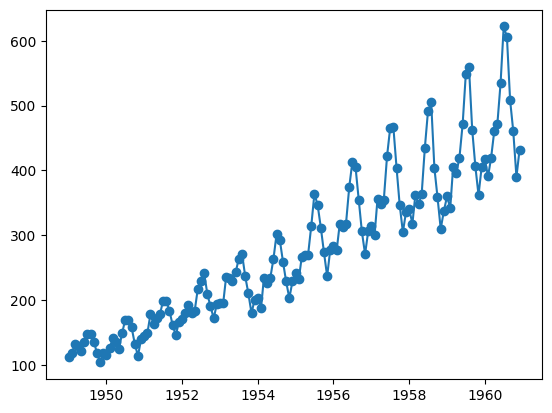

In [17]:
plt.plot(df['Month'],df['#Passengers'])
plt.scatter(df['Month'],df['#Passengers'])
plt.show()

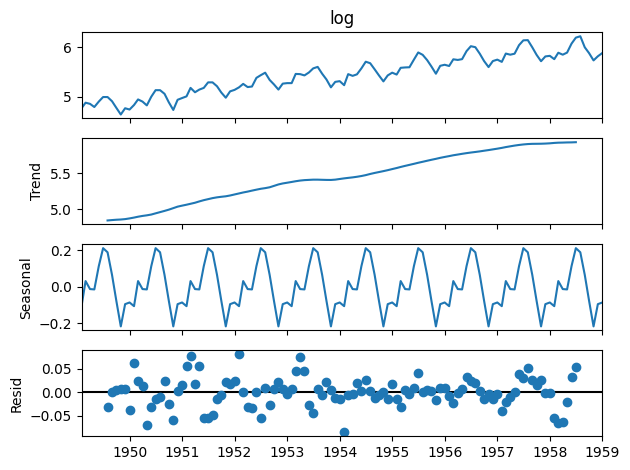

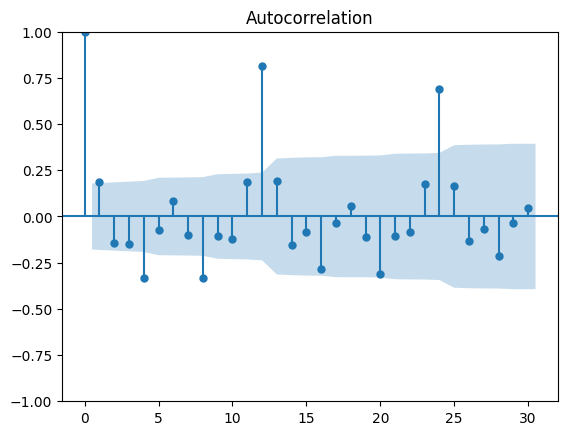

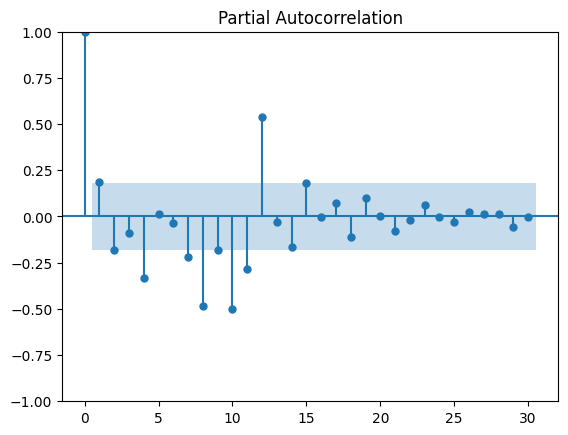

C:\Users\Jagdish singh\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Jagdish singh\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Jagdish singh\AppData\Local\Temp\ipykernel_23980\476043543.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['forecast'] = forecast


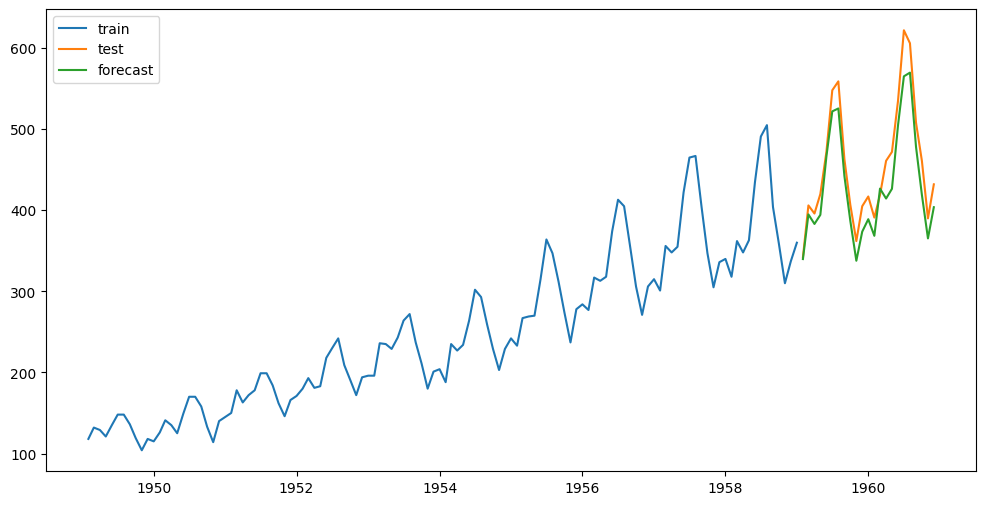

C:\Users\Jagdish singh\AppData\Local\Temp\ipykernel_23980\476043543.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], future, label='future')


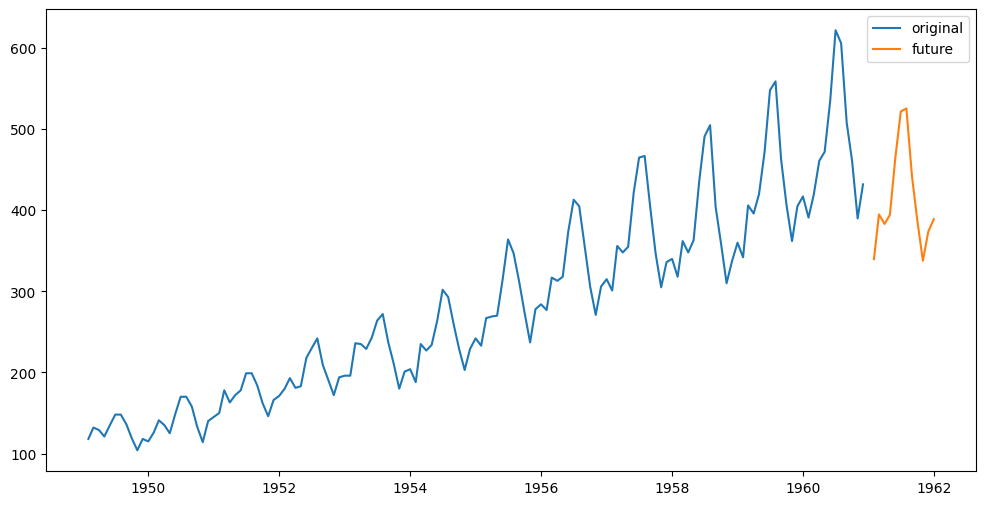

29.675470503317573
26.57191674244119


In [18]:
df.set_index('Month', inplace=True)

df['log'] = np.log(df['#Passengers'])
df['diff'] = df['log'].diff()
df.dropna(inplace=True)

train = df.iloc[:120]
test = df.iloc[120:]

decomp = seasonal_decompose(train['log'], model='additive', period=12)
decomp.plot()
plt.show()

adf_result = adfuller(train['diff'])

plot_acf(train['diff'], lags=30)
plot_pacf(train['diff'], lags=30)
plt.show()

model = SARIMAX(train['log'], order=(2,1,2), seasonal_order=(1,1,1,12))
model_fit = model.fit()

forecast_log = model_fit.forecast(steps=len(test))
forecast = np.exp(forecast_log)

test['forecast'] = forecast

rmse = np.sqrt(mean_squared_error(np.exp(test['log']), test['forecast']))
mae = mean_absolute_error(np.exp(test['log']), test['forecast'])

plt.figure(figsize=(12,6))
plt.plot(np.exp(train['log']), label='train')
plt.plot(np.exp(test['log']), label='test')
plt.plot(test['forecast'], label='forecast')
plt.legend()
plt.show()

future_log = model_fit.forecast(steps=12)
future = np.exp(future_log)

plt.figure(figsize=(12,6))
plt.plot(df['#Passengers'], label='original')
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], future, label='future')
plt.legend()
plt.show()

print(rmse)
print(mae)